# Лабораторная 4: генерация лиц на CelebA

**Задача:** предобработка лиц (MTCNN), **безусловная** генерация (WGAN-GP), преобразование в **условную** модель по полу, метрики **FID** и **IS**, кривые обучения.

**Датасет:** [CelebA](https://www.kaggle.com/datasets/jessicali9530/celeba-dataset) → `data/celeba/`.


## 0. Зависимости


In [1]:
# %pip install -r requirements.txt


## 1. Конфигурация и устройство


In [2]:
from __future__ import annotations

import json
import os
import random
import time
from dataclasses import dataclass, asdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.utils import make_grid, save_image
from tqdm.auto import tqdm

LAB_ROOT = Path.cwd()
DATA_DIR = LAB_ROOT / "data"
CELEBA_ROOT = Path(os.environ.get("CELEBA_ROOT", LAB_ROOT / "data" / "celeba"))
PROCESSED_DIR = LAB_ROOT / "data" / "processed_faces"
CHECKPOINT_DIR = LAB_ROOT / "checkpoints"
OUTPUT_DIR = LAB_ROOT / "outputs"
for p in (PROCESSED_DIR, CHECKPOINT_DIR, OUTPUT_DIR):
    p.mkdir(parents=True, exist_ok=True)


def pick_device() -> torch.device:
    forced = os.environ.get("DEVICE")
    if forced:
        return torch.device(forced)
    if torch.cuda.is_available():
        return torch.device("cuda:0")
    if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


DEVICE = pick_device()
SKIP_TRAIN = os.environ.get("SKIP_TRAIN", "0") == "1"
SKIP_PREPROCESS = os.environ.get("SKIP_PREPROCESS", "0") == "1"


@dataclass
class Config:
    img_size: int = 64
    z_dim: int = 128
    ngf: int = 64
    ndf: int = 64
    batch_size: int = int(os.environ.get("BATCH_SIZE", "128" if pick_device().type == "cuda" else "32"))
    lr: float = 1e-4
    beta1: float = 0.0
    beta2: float = 0.9
    n_critic: int = 5
    lambda_gp: float = 10.0
    max_samples: int = int(os.environ.get("MAX_SAMPLES", "30000"))
    epochs_uncond: int = int(os.environ.get("EPOCHS_UNCOND", "30"))
    epochs_cond: int = int(os.environ.get("EPOCHS_COND", "20"))
    num_workers: int = 2 if pick_device().type != "cpu" else 0
    seed: int = 42
    label_name: str = "Male"
    n_classes: int = 2


CFG = Config()
random.seed(CFG.seed)
np.random.seed(CFG.seed)
torch.manual_seed(CFG.seed)
if DEVICE.type == "cuda":
    torch.cuda.manual_seed_all(CFG.seed)

print("Device:", DEVICE)
print("Config:", asdict(CFG))
print("CelebA root:", CELEBA_ROOT)


Device: cuda:0
Config: {'img_size': 64, 'z_dim': 128, 'ngf': 64, 'ndf': 64, 'batch_size': 128, 'lr': 0.0001, 'beta1': 0.0, 'beta2': 0.9, 'n_critic': 5, 'lambda_gp': 10.0, 'max_samples': 30000, 'epochs_uncond': 30, 'epochs_cond': 20, 'num_workers': 2, 'seed': 42, 'label_name': 'Male', 'n_classes': 2}
CelebA root: C:\Users\Daria\Desktop\ITMO\cv-itmo\lab4\data\celeba


## 2. Предобработка: детекция и вырезание лиц (MTCNN)


In [3]:
RAW_DIR = DATA_DIR / "celeba_raw"


def download_kaggle_dataset(slug, dst):
    if dst.exists() and any(dst.iterdir()):
        print(f"Датасет уже существует: {dst}")
        return dst
    dst.mkdir(parents=True, exist_ok=True)
    ret = os.system(f'kaggle datasets download -d "{slug}" -p "{dst}" --unzip')
    return dst

RAW_DIR = download_kaggle_dataset("jessicali9530/celeba-dataset", RAW_DIR)

IMG_DIR_CANDIDATES = list(RAW_DIR.rglob("img_align_celeba"))
IMG_RAW_DIR = IMG_DIR_CANDIDATES[0] if IMG_DIR_CANDIDATES else RAW_DIR / "img_align_celeba"
if not list(IMG_RAW_DIR.glob("*.jpg")):
    IMG_RAW_DIR = IMG_RAW_DIR / "img_align_celeba"

ATTR_CSV_CANDIDATES = list(RAW_DIR.rglob("list_attr_celeba.csv"))
ATTR_CSV = ATTR_CSV_CANDIDATES[0] if ATTR_CSV_CANDIDATES else RAW_DIR / "list_attr_celeba.csv"

print(f"Изображений: {len(list(IMG_RAW_DIR.glob('*.jpg')))}")

Датасет уже существует: C:\Users\Daria\Desktop\ITMO\cv-itmo\lab4\data\celeba_raw
Изображений: 202599


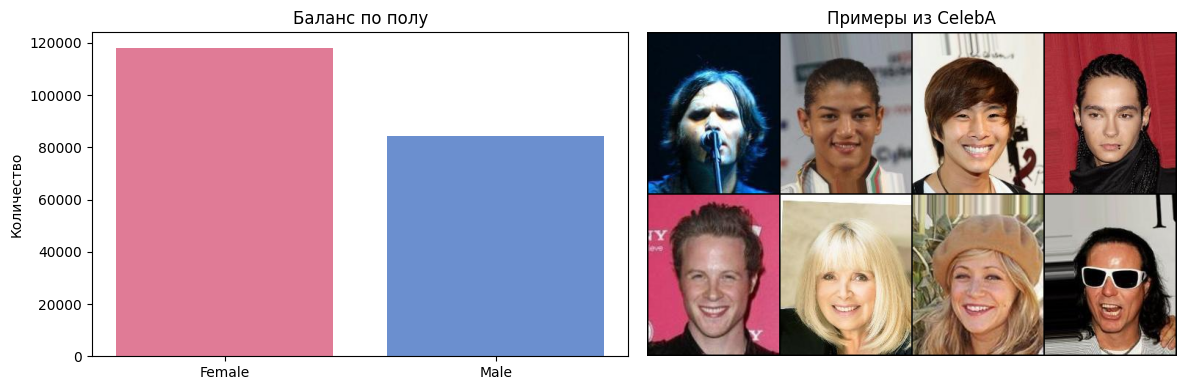

In [5]:
attrs = pd.read_csv(ATTR_CSV)
if attrs.columns[0] != "image_id":
    attrs = attrs.rename(columns={attrs.columns[0]: "image_id"})

n_male = (attrs["Male"] == 1).sum()
n_female = (attrs["Male"] == -1).sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(["Female", "Male"], [n_female, n_male], color=["#e07b96", "#6b8fcf"])
axes[0].set_title("Баланс по полу")
axes[0].set_ylabel("Количество")

sample_files = random.sample(list(IMG_RAW_DIR.glob("*.jpg")), 8)
grid_img = make_grid(
    [transforms.ToTensor()(Image.open(f)) for f in sample_files], nrow=4
)
axes[1].imshow(grid_img.permute(1, 2, 0))
axes[1].axis("off")
axes[1].set_title("Примеры из CelebA")
plt.tight_layout()
plt.show()

In [6]:
from facenet_pytorch import MTCNN

mtcnn = MTCNN(
    image_size=CFG.img_size,
    margin=20,
    min_face_size=20,
    keep_all=False,
    post_process=False,
    device=str(DEVICE),
)

def crop_face(img):
    try:
        face_tensor = mtcnn(img)
        if face_tensor is not None:
            return Image.fromarray(face_tensor.permute(1, 2, 0).numpy().astype(np.uint8))
    except Exception:
        pass
    return None


def build_face_dataset(img_dir, attr_df, out_dir, max_images=None):
    if out_dir.exists() and len(list(out_dir.glob("*.jpg"))) > 100:
        saved = pd.read_csv(out_dir / "labels.csv")
        print(f"Лица уже обработаны: {len(saved)} шт.")
        return saved

    out_dir.mkdir(parents=True, exist_ok=True)
    all_files = sorted(img_dir.glob("*.jpg"))
    if max_images:
        all_files = all_files[:max_images]

    attr_indexed = attr_df.set_index("image_id")
    records = []
    for img_path in tqdm(all_files, desc="Crop faces"):
        img = Image.open(img_path).convert("RGB")
        cropped_img = crop_face(img)
        if cropped_img is None:
            continue
        cropped_img.save(out_dir / img_path.name, quality=95)
        try:
            label = 1 if attr_indexed.loc[img_path.name]["Male"] == 1 else 0
        except KeyError:
            label = -1
        records.append({"filename": img_path.name, "label": label})

    df = pd.DataFrame(records)
    df.to_csv(out_dir / "labels.csv", index=False)
    print(f"Сохранено {len(df)} лиц в {out_dir}")
    return df


labels_df = build_face_dataset(IMG_RAW_DIR, attrs, PROCESSED_DIR, max_images=CFG.max_samples)
print(labels_df["label"].value_counts().rename({0: "Female", 1: "Male", -1: "Unknown"}))

Лица уже обработаны: 29960 шт.
label
Female    17307
Male      12653
Name: count, dtype: int64


## 3. Dataset и DataLoader


In [7]:
class FaceDataset(Dataset):
    def __init__(self, faces_dir, labels_df):
        self.faces_dir = faces_dir
        self.df = labels_df[labels_df["label"] != -1].reset_index(drop=True)
        self.transform = transforms.Compose([
            transforms.Resize(CFG.img_size),
            transforms.CenterCrop(CFG.img_size),
            transforms.ToTensor(),
            transforms.Normalize([0.5]*3, [0.5]*3),  # → [-1, 1]
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(self.faces_dir / row["filename"]).convert("RGB")
        return self.transform(img), int(row["label"])

dataset = FaceDataset(PROCESSED_DIR, labels_df)
loader = DataLoader(dataset, batch_size=CFG.batch_size, shuffle=True,
                    num_workers=0, pin_memory=True, drop_last=True)

## 4. Архитектура WGAN-GP (DCGAN-style)

**Практики из WGAN-GP:** InstanceNorm в генераторе и критике (без batch-зависимости), без sigmoid, gradient penalty, `betas=(0, 0.9)` для Adam.


In [8]:
def weights_init(m: nn.Module) -> None:
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.normal_(m.weight.data, 0.0, 0.02)


def make_generator(in_channels: int, ngf: int = CFG.ngf, nc: int = 3) -> nn.Sequential:
    return nn.Sequential(
        nn.ConvTranspose2d(in_channels, ngf * 8, 4, 1, 0, bias=False),
        nn.InstanceNorm2d(ngf * 8, affine=True),
        nn.ReLU(True),
        nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
        nn.InstanceNorm2d(ngf * 4, affine=True),
        nn.ReLU(True),
        nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
        nn.InstanceNorm2d(ngf * 2, affine=True),
        nn.ReLU(True),
        nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
        nn.InstanceNorm2d(ngf, affine=True),
        nn.ReLU(True),
        nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
        nn.Tanh(),
    )


def make_critic(in_channels: int, ndf: int = CFG.ndf) -> nn.Sequential:
    return nn.Sequential(
        nn.Conv2d(in_channels, ndf, 4, 2, 1, bias=False),
        nn.LeakyReLU(0.2, inplace=True),
        nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
        nn.InstanceNorm2d(ndf * 2, affine=True),
        nn.LeakyReLU(0.2, inplace=True),
        nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
        nn.InstanceNorm2d(ndf * 4, affine=True),
        nn.LeakyReLU(0.2, inplace=True),
        nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
        nn.InstanceNorm2d(ndf * 8, affine=True),
        nn.LeakyReLU(0.2, inplace=True),
        nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False),
    )


class Generator(nn.Module):
    def __init__(self, z_dim: int = CFG.z_dim):
        super().__init__()
        self.z_dim = z_dim
        self.net = make_generator(z_dim)

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = make_critic(3)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x).view(-1)


class ConditionalGenerator(nn.Module):
    # embedding метки конкатенируется к z по каналам — удобный перенос весов из безусловной G

    def __init__(self, n_classes: int = CFG.n_classes, z_dim: int = CFG.z_dim):
        super().__init__()
        self.z_dim = z_dim
        self.label_emb = nn.Embedding(n_classes, z_dim)
        self.net = make_generator(z_dim * 2)

    def forward(self, z: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        emb = self.label_emb(y).unsqueeze(-1).unsqueeze(-1)
        return self.net(torch.cat([z, emb], dim=1))

    def load_from_unconditional(self, g: Generator) -> int:
        src = g.net.state_dict()
        dst = self.net.state_dict()
        transferred = 0
        for k, v in dst.items():
            if k in src and src[k].shape == v.shape:
                dst[k] = src[k]
                transferred += 1
        self.net.load_state_dict(dst)
        return transferred


class ConditionalDiscriminator(nn.Module):
    # one-hot метки добавляются как дополнительные каналы входа

    def __init__(self, n_classes: int = CFG.n_classes):
        super().__init__()
        self.n_classes = n_classes
        self.net = make_critic(3 + n_classes)

    def forward(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        b, _, h, w = x.shape
        onehot = torch.zeros(b, self.n_classes, h, w, device=x.device)
        onehot.scatter_(1, y.view(b, 1, 1, 1).expand(b, 1, h, w), 1.0)
        return self.net(torch.cat([x, onehot], dim=1)).view(-1)

    def load_from_unconditional(self, d: Discriminator) -> int:
        src = d.net.state_dict()
        dst = self.net.state_dict()
        transferred = 0
        for k, v in dst.items():
            if k in src and src[k].shape == v.shape:
                dst[k] = src[k]
                transferred += 1
        self.net.load_state_dict(dst)
        return transferred


def gradient_penalty(disc, real, fake, conditional=False, labels=None):
    batch_size = real.size(0)
    alpha = torch.rand(batch_size, 1, 1, 1, device=real.device)
    interpolates = (alpha * real + (1 - alpha) * fake).requires_grad_(True)
    if conditional:
        scores = disc(interpolates, labels)
    else:
        scores = disc(interpolates)
    grads = torch.autograd.grad(
        outputs=scores,
        inputs=interpolates,
        grad_outputs=torch.ones_like(scores),
        create_graph=True,
        retain_graph=True,
    )[0]
    grads = grads.view(batch_size, -1)
    return ((grads.norm(2, dim=1) - 1) ** 2).mean()


G = Generator().to(DEVICE)
D = Discriminator().to(DEVICE)
G.apply(weights_init)
D.apply(weights_init)

# Фиксированный шум — нагляднее сравнивать прогресс между эпохами
FIXED_Z = torch.randn(64, CFG.z_dim, 1, 1, device=DEVICE)
FIXED_LABELS = torch.cat(
    [torch.zeros(32, dtype=torch.long, device=DEVICE), torch.ones(32, dtype=torch.long, device=DEVICE)]
)

print("Generator params (K):", sum(p.numel() for p in G.parameters()) // 1000)


Generator params (K): 3806


## 5. Обучение безусловной WGAN-GP


In [13]:
SKIP_TRAIN = True

In [14]:
def sample_z(batch_size: int) -> torch.Tensor:
    return torch.randn(batch_size, CFG.z_dim, 1, 1, device=DEVICE)


def save_sample_grid(
    generator,
    path: Path,
    n: int = 64,
    conditional: bool = False,
    label: int | None = None,
    fixed: bool = True,
):
    generator.eval()
    with torch.no_grad():
        z = FIXED_Z[:n] if fixed else sample_z(n)
        if conditional:
            assert label is not None
            if fixed:
                y = FIXED_LABELS[:n]
            else:
                y = torch.full((n,), label, dtype=torch.long, device=DEVICE)
            fake = generator(z, y)
        else:
            fake = generator(z)
    save_image(make_grid(fake, nrow=8, normalize=True, value_range=(-1, 1)), path)
    generator.train()


def train_wgan_gp(
    Gm: nn.Module,
    Dm: nn.Module,
    loader: DataLoader,
    epochs: int,
    conditional: bool = False,
    history_key: str = "uncond",
):
    opt_g = torch.optim.Adam(Gm.parameters(), lr=CFG.lr, betas=(CFG.beta1, CFG.beta2))
    opt_d = torch.optim.Adam(Dm.parameters(), lr=CFG.lr, betas=(CFG.beta1, CFG.beta2))

    hist = {"epoch": [], "d_loss": [], "g_loss": [], "gp": [], "w_dist": []}

    for epoch in range(1, epochs + 1):
        d_losses, g_losses, gps, w_dists = [], [], [], []

        for batch in tqdm(loader, desc=f"{history_key} ep {epoch}/{epochs}", leave=False):
            real, labels = batch
            real = real.to(DEVICE)
            if conditional:
                labels = labels.to(DEVICE)
            else:
                labels = None

            for _ in range(CFG.n_critic):
                z = sample_z(real.size(0))
                if conditional:
                    fake = Gm(z, labels).detach()
                    d_real = Dm(real, labels).mean()
                    d_fake = Dm(fake, labels).mean()
                    gp = gradient_penalty(Dm, real, fake, conditional=True, labels=labels)
                else:
                    fake = Gm(z).detach()
                    d_real = Dm(real).mean()
                    d_fake = Dm(fake).mean()
                    gp = gradient_penalty(Dm, real, fake)

                d_loss = d_fake - d_real + CFG.lambda_gp * gp
                opt_d.zero_grad(set_to_none=True)
                d_loss.backward()
                opt_d.step()

            z = sample_z(real.size(0))
            if conditional:
                fake = Gm(z, labels)
                g_loss = -Dm(fake, labels).mean()
            else:
                fake = Gm(z)
                g_loss = -Dm(fake).mean()

            opt_g.zero_grad(set_to_none=True)
            g_loss.backward()
            opt_g.step()

            d_losses.append(float(d_loss.item()))
            g_losses.append(float(g_loss.item()))
            gps.append(float(gp.item()))
            w_dists.append(float((d_real - d_fake).item()))

        hist["epoch"].append(epoch)
        hist["d_loss"].append(float(np.mean(d_losses)))
        hist["g_loss"].append(float(np.mean(g_losses)))
        hist["gp"].append(float(np.mean(gps)))
        hist["w_dist"].append(float(np.mean(w_dists)))
        print(
            f"[{history_key}] epoch {epoch}: D={hist['d_loss'][-1]:.3f}, "
            f"G={hist['g_loss'][-1]:.3f}, GP={hist['gp'][-1]:.3f}, W={hist['w_dist'][-1]:.3f}"
        )

        if epoch % 5 == 0 or epoch == epochs:
            if conditional:
                save_sample_grid(
                    Gm, OUTPUT_DIR / f"samples_cond_ep{epoch}.png", conditional=True, label=0, fixed=True
                )
            else:
                save_sample_grid(Gm, OUTPUT_DIR / f"samples_uncond_ep{epoch}.png", fixed=True)

    return hist


history: dict = {"uncond": {}, "cond": {}}

if not SKIP_TRAIN:
    history["uncond"] = train_wgan_gp(G, D, loader, CFG.epochs_uncond, conditional=False)
    torch.save(G.state_dict(), CHECKPOINT_DIR / "generator_uncond.pt")
    torch.save(D.state_dict(), CHECKPOINT_DIR / "discriminator_uncond.pt")
else:
    G.load_state_dict(torch.load(CHECKPOINT_DIR / "generator_uncond.pt", map_location=DEVICE, weights_only=True))
    D.load_state_dict(torch.load(CHECKPOINT_DIR / "discriminator_uncond.pt", map_location=DEVICE, weights_only=True))
    print("Loaded unconditional checkpoints (SKIP_TRAIN=1)")


Loaded unconditional checkpoints (SKIP_TRAIN=1)


## 6. Преобразование в условную модель и дообучение

Переносим совместимые свёрточные веса из безусловной сети (все слои, кроме первого — у него другая размерность входа из-за метки).


In [16]:
SKIP_TRAIN = False

In [18]:
G_cond = ConditionalGenerator().to(DEVICE)
D_cond = ConditionalDiscriminator().to(DEVICE)

n_g = G_cond.load_from_unconditional(G)
n_d = D_cond.load_from_unconditional(D)
print(f"Transferred G layers: {n_g}, D layers: {n_d}")

if not SKIP_TRAIN:
    history["cond"] = train_wgan_gp(
        G_cond, D_cond, loader, CFG.epochs_cond, conditional=True, history_key="cond"
    )
    torch.save(G_cond.state_dict(), CHECKPOINT_DIR / "generator_cond.pt")
    torch.save(D_cond.state_dict(), CHECKPOINT_DIR / "discriminator_cond.pt")
else:
    G_cond.load_state_dict(torch.load(CHECKPOINT_DIR / "generator_cond.pt", map_location=DEVICE, weights_only=True))
    D_cond.load_state_dict(torch.load(CHECKPOINT_DIR / "discriminator_cond.pt", map_location=DEVICE, weights_only=True))
    print("Loaded conditional checkpoints (SKIP_TRAIN=1)")

save_sample_grid(G_cond, OUTPUT_DIR / "samples_cond_final.png", conditional=True, label=0, fixed=True)


Transferred G layers: 12, D layers: 10


cond ep 1/20:   0%|          | 0/234 [00:00<?, ?it/s]

[cond] epoch 1: D=-9.590, G=35.313, GP=0.156, W=11.155


cond ep 2/20:   0%|          | 0/234 [00:00<?, ?it/s]

[cond] epoch 2: D=-8.386, G=20.377, GP=0.078, W=9.162


...

[cond] epoch 18: D=-9.072, G=73.122, GP=0.155, W=10.622


cond ep 19/20:   0%|          | 0/234 [00:00<?, ?it/s]

[cond] epoch 19: D=-9.241, G=72.877, GP=0.154, W=10.779


cond ep 20/20:   0%|          | 0/234 [00:00<?, ?it/s]

[cond] epoch 20: D=-9.192, G=74.403, GP=0.156, W=10.754


## 7. Кривые обучения и прогресс генерации


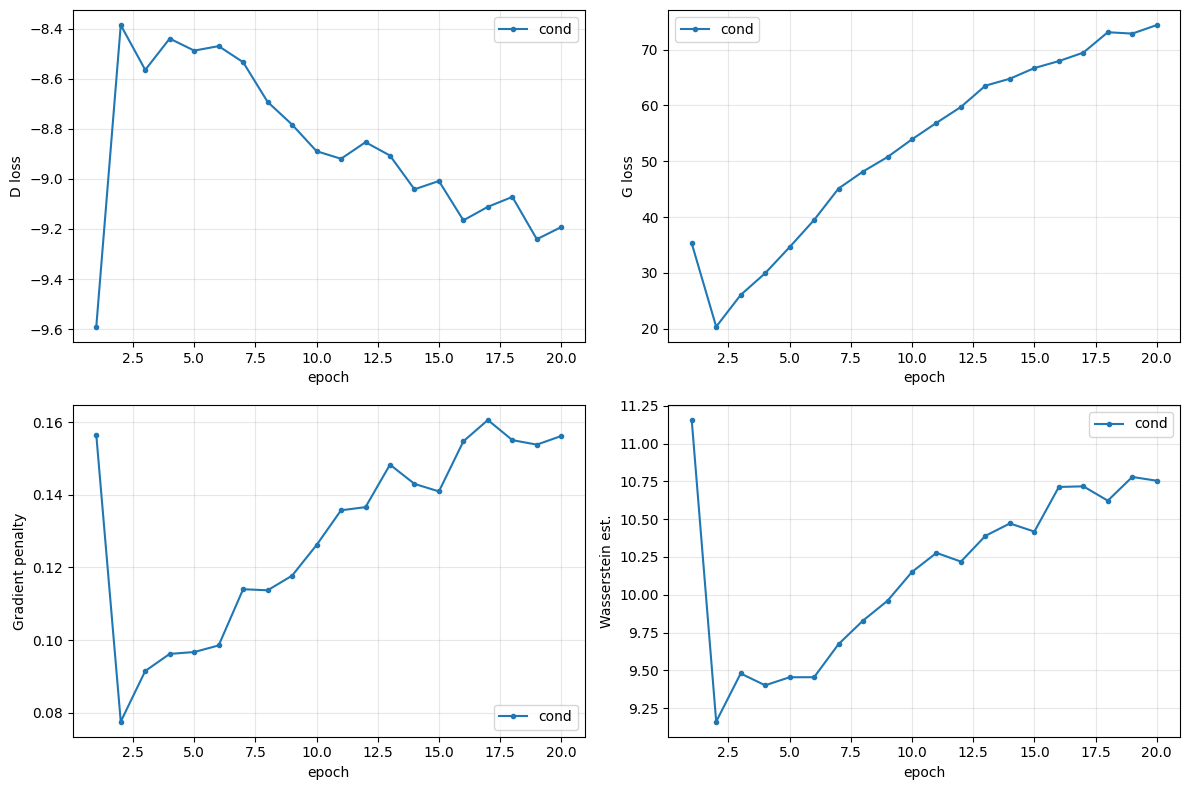

Saved training history


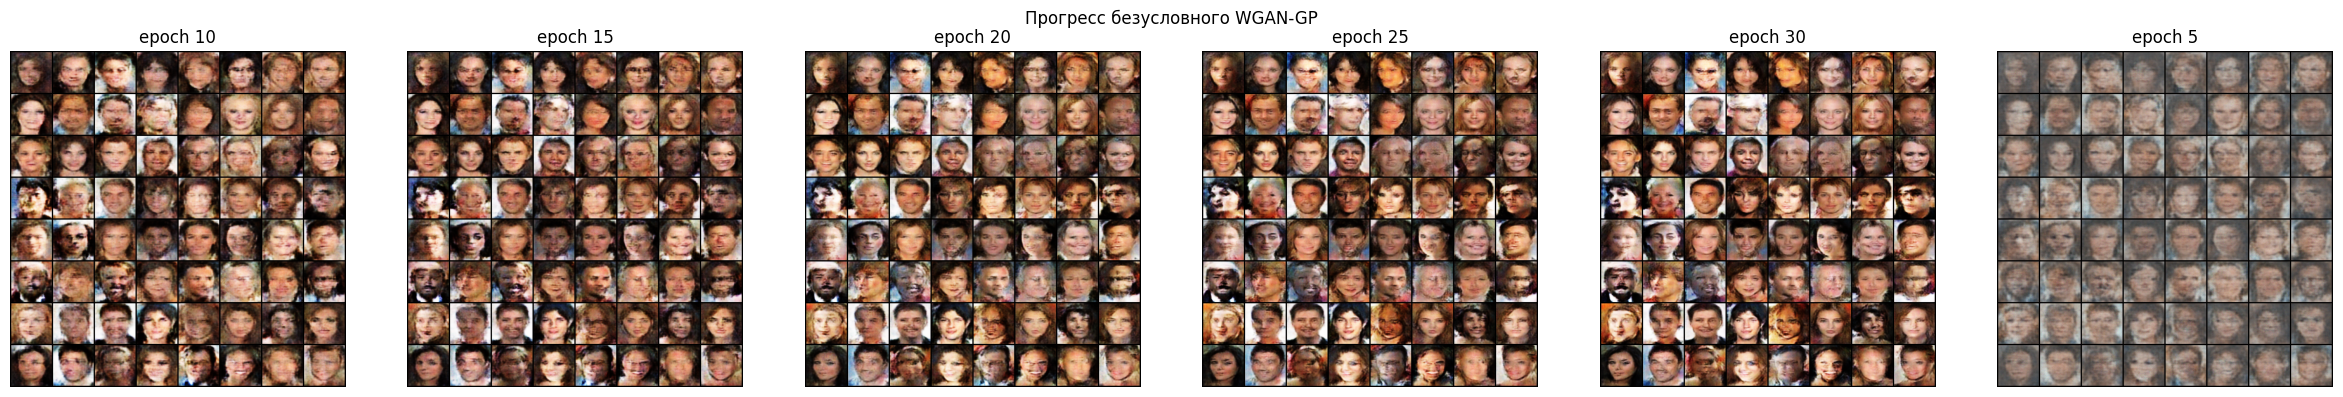

In [19]:
def plot_training_curves(history_dict: dict, out_path: Path):
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    metrics = [
        ("d_loss", "D loss"),
        ("g_loss", "G loss"),
        ("gp", "Gradient penalty"),
        ("w_dist", "Wasserstein est."),
    ]

    for ax, (key, title) in zip(axes.ravel(), metrics):
        if history_dict.get("uncond", {}).get("epoch"):
            ax.plot(history_dict["uncond"]["epoch"], history_dict["uncond"][key], label="uncond", marker="o", ms=3)
        if history_dict.get("cond", {}).get("epoch"):
            ax.plot(history_dict["cond"]["epoch"], history_dict["cond"][key], label="cond", marker="o", ms=3)
        ax.set_xlabel("epoch")
        ax.set_ylabel(title)
        ax.grid(True, alpha=0.3)
        ax.legend()

    fig.tight_layout()
    fig.savefig(out_path, dpi=150)
    plt.show()


if history["uncond"] or history["cond"]:
    plot_training_curves(history, OUTPUT_DIR / "training_curves.png")

with open(OUTPUT_DIR / "training_history.json", "w") as f:
    json.dump(history, f, indent=2)
print("Saved training history")

# Прогресс по эпохам (если есть сохранённые сэмплы)
sample_imgs = sorted(OUTPUT_DIR.glob("samples_uncond_ep*.png"))
if sample_imgs:
    fig, axes = plt.subplots(1, len(sample_imgs), figsize=(4 * len(sample_imgs), 4))
    if len(sample_imgs) == 1:
        axes = [axes]
    for ax, p in zip(axes, sample_imgs):
        ax.imshow(plt.imread(p))
        ax.set_title(p.stem.replace("samples_uncond_ep", "epoch "))
        ax.axis("off")
    plt.suptitle("Прогресс безусловного WGAN-GP")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "uncond_progress.png", dpi=150)
    plt.show()


## 8. Метрики FID и Inception Score (IS)

- **FID** — расстояние между распределениями реальных и сгенерированных изображений (меньше = лучше).
- **IS** — качество и разнообразие генерации (больше = лучше).


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to C:\Users\Daria/.cache\torch\hub\checkpoints\weights-inception-2015-12-05-6726825d.pth


FID (безусловный): 69.36
FID (условный):    93.45
IS  (безусловный): 2.13
IS  (условный):    2.29


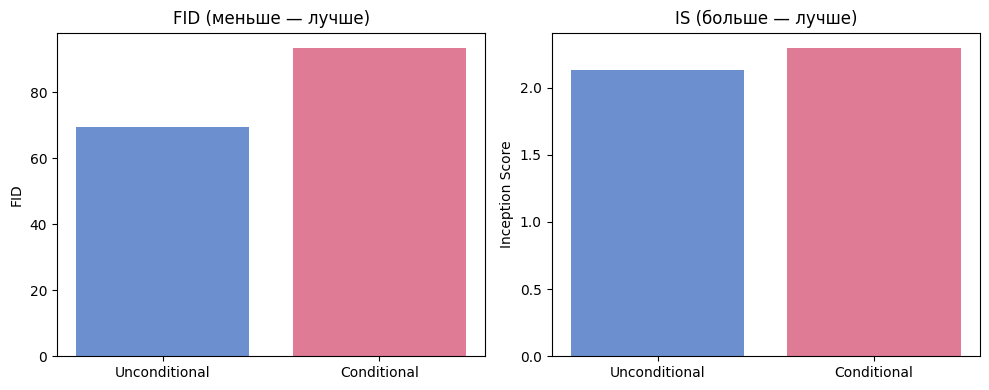

In [27]:
REAL_DIR = OUTPUT_DIR / "real_eval"
FAKE_UNCOND_DIR = OUTPUT_DIR / "fake_uncond"
FAKE_COND_DIR = OUTPUT_DIR / "fake_cond"
for d in (REAL_DIR, FAKE_UNCOND_DIR, FAKE_COND_DIR):
    d.mkdir(parents=True, exist_ok=True)

N_FID = 5000


def export_real_images(faces_dir: Path, out_dir: Path, limit: int = N_FID) -> None:
    out_dir.mkdir(parents=True, exist_ok=True)
    for old in out_dir.glob("*.jpg"):
        old.unlink()
    all_faces = list(faces_dir.glob("*.jpg"))
    if not all_faces:
        raise FileNotFoundError(f"Нет .jpg в {faces_dir}")
    for i, f in enumerate(random.sample(all_faces, min(limit, len(all_faces)))):
        Image.open(f).convert("RGB").save(out_dir / f"{i:05d}.jpg", quality=95)


@torch.no_grad()
def export_generated(Gm, out_dir: Path, n: int = N_FID, conditional=False, labels: torch.Tensor | None = None):
    out_dir.mkdir(parents=True, exist_ok=True)
    for old in out_dir.glob("*.jpg"):
        old.unlink()
    Gm.eval()
    bs = 128
    saved = 0
    while saved < n:
        cur = min(bs, n - saved)
        z = sample_z(cur)
        if conditional:
            y = labels[saved : saved + cur].to(DEVICE)
            imgs = Gm(z, y)
        else:
            imgs = Gm(z)
        for j in range(cur):
            save_image(imgs[j], out_dir / f"{saved + j:05d}.jpg", normalize=True, value_range=(-1, 1))
        saved += cur


export_real_images(PROCESSED_DIR, REAL_DIR, limit=N_FID)
export_generated(G, FAKE_UNCOND_DIR, n=N_FID)

cond_labels = torch.cat(
    [
        torch.zeros(N_FID // 2, dtype=torch.long),
        torch.ones(N_FID - N_FID // 2, dtype=torch.long),
    ]
)
export_generated(G_cond, FAKE_COND_DIR, n=N_FID, conditional=True, labels=cond_labels)

from torch_fidelity import calculate_metrics

fid_device = "cuda" if DEVICE.type == "cuda" else "cpu"

metrics_uncond = calculate_metrics(
    input1=str(FAKE_UNCOND_DIR),
    input2=str(REAL_DIR),
    cuda=(fid_device == "cuda"),
    isc=True,
    fid=True,
    verbose=False,
)

metrics_cond = calculate_metrics(
    input1=str(FAKE_COND_DIR),
    input2=str(REAL_DIR),
    cuda=(fid_device == "cuda"),
    isc=True,
    fid=True,
    verbose=False,
)

metrics = {"unconditional": metrics_uncond, "conditional": metrics_cond}

with open(OUTPUT_DIR / "metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

fid_u = metrics_uncond["frechet_inception_distance"]
fid_c = metrics_cond["frechet_inception_distance"]
is_u = metrics_uncond["inception_score_mean"]
is_c = metrics_cond["inception_score_mean"]

print(f"FID (безусловный): {fid_u:.2f}")
print(f"FID (условный):    {fid_c:.2f}")
print(f"IS  (безусловный): {is_u:.2f}")
print(f"IS  (условный):    {is_c:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(["Unconditional", "Conditional"], [fid_u, fid_c], color=["#6b8fcf", "#e07b96"])
axes[0].set_title("FID (меньше — лучше)")
axes[0].set_ylabel("FID")
axes[1].bar(["Unconditional", "Conditional"], [is_u, is_c], color=["#6b8fcf", "#e07b96"])
axes[1].set_title("IS (больше — лучше)")
axes[1].set_ylabel("Inception Score")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "metrics_bars.png", dpi=150)
plt.show()
